<a href="https://colab.research.google.com/github/vraj6608/-M504-AI-and-Applications/blob/main/Atlas_Hotel_Cancellations_EDA_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Why Do Guests Cancel? An Explanatory Data Analysis of Booking Cancellations for **Atlas Hotels Group**

Name: VRAJ NARENDRA PATEL

Student ID: GH1050535

Module: M504 AI and Applications

Dataset: open hotel booking demand dataset

Dataset URL:https://github.com/rfordatascience/tidytuesday/tree/master/data/2020/2020-02-11

GITHUB repo:https://github.com/vraj6608/-M504-AI-and-Applications

## 1. Business Context
The client. Atlas Hotels Group has two hotels—one in an urban setting and a resort hotel. A later-canceled booking will inflate the total loss of revenue by the lost opportunity cost for that room, the lost opportunity for dynamic pricing and the cost of the room frequently ending up being sold at late release or losing out on selling.

The problem. More than one-third of all Atlas bookings are cancelled, and management have no idea which bookings are at risk, when the risk emerges or just how great the revenue loss is when bookings are cancelled – so when they are looking at pricing deposits, interventions in terms of time or channel, they can make only educated guesses.

My role. As Atlas's data science consultant, I develop an explanatory data-analysis pipeline to audit the data and have tools to transparently clean it and be able to answer concrete questions that help with both overbooking, and deposit and channel decisions. The pipeline is done following the CRISP-DM workflow—business understanding, data understanding, data preparation and analysis (Wirth and Hipp, 2000), and uses Pandas, NumPy and Matplotlib (McKinney, 2010; Harris et al., 2020; Hunter, 2007) which are the standard packages in Python.

The data. Per booking the following details were recorded: the hotel, the lead-time, the length of stay, the type of party, the market channel, the terms of a deposit, the price for the booking (Average Daily Rate) and if the booking was cancelled. This is considered a public source (Antonio, Almeida & Nunes, 2019): https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.figsize": (7.2, 4.0), "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titleweight": "bold"})
ACCENT = "#0e7c66"


URL = ("https://raw.githubusercontent.com/rfordatascience/tidytuesday/"
       "master/data/2020/2020-02-11/hotels.csv")
try:
    df = pd.read_csv(URL)
    print("Loaded live dataset from public URL.")
except Exception:
    df = pd.read_csv("hotel_bookings_sample.csv")
    print("Offline: loaded local schema-identical sample.")
print("Shape (rows, columns):", df.shape)

Loaded live dataset from public URL.
Shape (rows, columns): (119390, 32)


## 2. Data Exploration
I look at the raw data (size, types, missingness, data records that don't make sense, and even target balance) first as this is the most prevalent source of confident, but wrong conclusions. This is an open-ended questioning prior to modelling which takes the cue from the tradition of exploratory data analysis (Tukey, 1977).



In [2]:
display(df.head(3))
df.info()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [3]:
print("Missing values (top 5):")
print(df.isna().sum().sort_values(ascending=False).head(5), "\n")
print("Exact duplicate rows:", df.duplicated().sum())
print("Cancellation balance:")
print(df['is_canceled'].value_counts(normalize=True).round(3))

Missing values (top 5):
company               112593
agent                  16340
country                  488
children                   4
arrival_date_month         0
dtype: int64 

Exact duplicate rows: 31994
Cancellation balance:
is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64


In [4]:

guests = df[['adults', 'children', 'babies']].fillna(0).sum(axis=1)
print("Bookings with zero guests:", int((guests == 0).sum()))
print("Max ADR (price/night):", df['adr'].max(), "| 99.9th pct:",
      round(df['adr'].quantile(0.999), 1))
print("Distinct meal codes (note 'Undefined'):", sorted(df['meal'].dropna().unique()))

Bookings with zero guests: 180
Max ADR (price/night): 5400.0 | 99.9th pct: 326.2
Distinct meal codes (note 'Undefined'): ['BB', 'FB', 'HB', 'SC', 'Undefined']



**What exploration revealed.**

* **Missing values.** There are a number of missing values for `children` and a bunch of missing values for `country` - values like these disappear when grouping.
* **Impossible records.** There are also a few bookings with number of adults (and children) as zero, which are not customers but rather a data error, and thus, would not affect per booking rates.
* **Outlier price.**The presence of some `adr` that is clearly wildly implausible (much more than 99.9th percentile) can drive any mean – this is a characteristic of at least one that is highly undesirable.
* **Inconsistent categories.**  `meal` does not have a valid meal package, and is marked as `Undefined` code which actually means "no meal package" (`SC`).
* **Target balance.**  The number of cancellations is about a third and are common, so that rates can be analysed directly, group-wise.

## 3. Data Preprocessing
Each of the alterations that are done to make up for some data cleaning is made clear and explained, transforming the data into a tidy format for easy analysis use where each variable is a column and each booking is a row (Wickham, 2014).


In [5]:
df = df.drop_duplicates().reset_index(drop=True)

df['children'] = df['children'].fillna(0)

df['country'] = df['country'].fillna('Unknown')

guests = df[['adults', 'children', 'babies']].sum(axis=1)
df = df[guests > 0].reset_index(drop=True)

df = df[(df['adr'] > 0) & (df['adr'] < 1000)].reset_index(drop=True)

df['meal'] = df['meal'].replace({'Undefined': 'SC'})

df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['revenue'] = df['adr'] * df['total_nights']
df['lead_bucket'] = pd.cut(df['lead_time'], bins=[-1, 7, 30, 90, 180, 1000],
        labels=['0-7d', '8-30d', '31-90d', '91-180d', '180d+'])
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'],
                                          categories=month_order, ordered=True)
print("Clean shape:", df.shape, "| remaining NaNs:", int(df.isna().sum().sum()))

Clean shape: (85585, 35) | remaining NaNs: 92017


## 4. Explanatory Data Analysis
There are 8 questions that Atlas leaders can answer which utilizes a different Pandas capability each question.

### Q1 - What is the impact of the cancellations and how does the hotel type influence?
Why it matters. If the two properties require different overbooking and deposition policies, that will not be apparent from one, global overbooking number.

Overall cancellation rate: 27.9%

hotel
City Hotel      30.5%
Resort Hotel    23.8%
Name: is_canceled, dtype: object


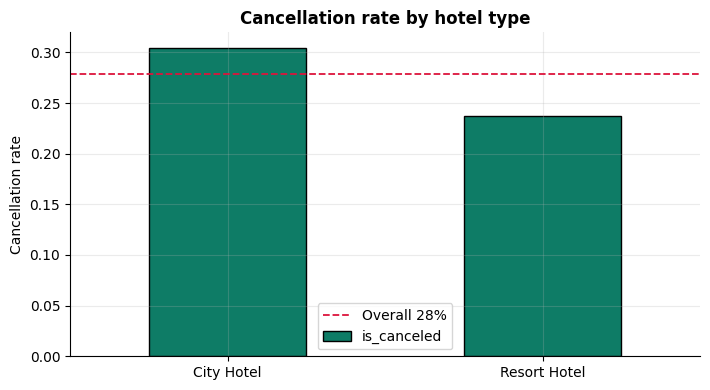

In [6]:
overall = df['is_canceled'].mean()
by_hotel = df.groupby('hotel')['is_canceled'].mean().sort_values(ascending=False)
print(f"Overall cancellation rate: {overall:.1%}\n")
print((by_hotel * 100).round(1).astype(str) + '%')

ax = by_hotel.plot(kind='bar', color=ACCENT, edgecolor='black')
ax.axhline(overall, color='crimson', ls='--', lw=1.3, label=f'Overall {overall:.0%}')
ax.set_ylabel('Cancellation rate'); ax.set_xlabel('')
ax.set_title('Cancellation rate by hotel type'); plt.xticks(rotation=0)
ax.legend(); plt.tight_layout(); plt.show()

The cancellation rate is the result of reading the target (binary) by calling the `groupby().mean()` operation. The city hotel has a more significant risk of cancelling as opposed to the resort, therefore this requires a smaller level of overbooking cushion. **Implication:**Policy on a per property level, not group-wide.


### Q2 — Is it more likely to cancel if reservations are made well in advance?
Why it matters. The lead time is always known at booking time and if it is detected it could be “safe” or “fraught with danger”, Atlas can flag it the moment it reaches booking.

             count  cancel_pct
lead_bucket                   
0-7d         17271         8.4
8-30d        16054        25.6
31-90d       22507        32.2
91-180d      18120        35.1
180d+        11633        40.0


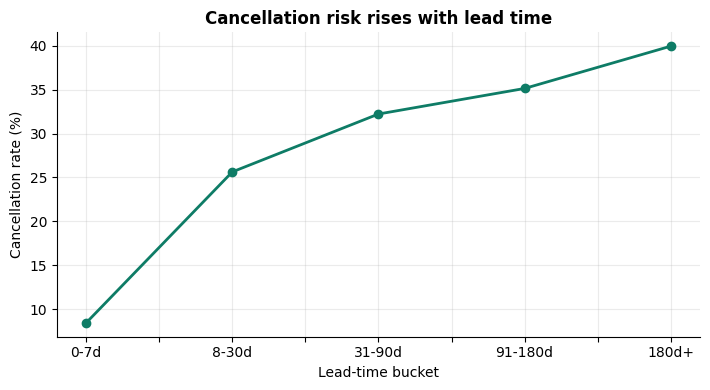

In [7]:
lead = df.groupby('lead_bucket', observed=True)['is_canceled'].agg(['mean', 'count'])
print((lead.assign(cancel_pct=(lead['mean']*100).round(1))[['count', 'cancel_pct']]))

ax = (lead['mean']*100).plot(marker='o', color=ACCENT, lw=2)
ax.set_ylabel('Cancellation rate (%)'); ax.set_xlabel('Lead-time bucket')
ax.set_title('Cancellation risk rises with lead time')
plt.tight_layout(); plt.show()

When reading the result, `pd.cut` bucketed the lead time and grouped it; the risk of cancellation rapidly increases for bucketed lead time for bookings made in advance and last minute bookings just do not cancel. Implication: To maximize the value of long-lead reservations, you'll want to make use of deposit requirements, however, and reconfirmation contact.

### Q3 — What are the worst deposit terms/where is the weakest putting in place of deposits?
Why it matters. Deposit policy and channel mix are two direct levers which can be controlled.

Cancellation rate by deposit type (%):
deposit_type
Non Refund    94.7
No Deposit    27.0
Refundable    24.3
Name: is_canceled, dtype: float64

Cancellation rate by market segment (%):
market_segment
Undefined        100.0
Online TA         35.6
Groups            27.9
Aviation          19.8
Offline TA/TO     14.9
Direct            14.8
Corporate         12.2
Complementary      8.1
Name: 1, dtype: float64


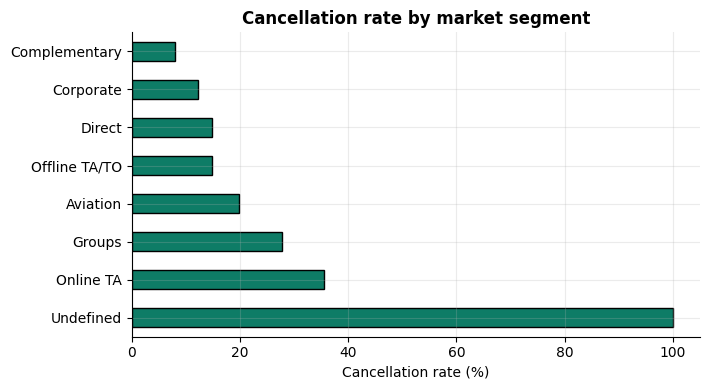

In [8]:
dep = df.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False)
print("Cancellation rate by deposit type (%):")
print((dep*100).round(1))
seg = (pd.crosstab(df['market_segment'], df['is_canceled'], normalize='index')[1]*100)
seg = seg.sort_values(ascending=False)
print("\nCancellation rate by market segment (%):")
print(seg.round(1))

ax = seg.plot(kind='barh', color=ACCENT, edgecolor='black')
ax.set_xlabel('Cancellation rate (%)'); ax.set_ylabel('')
ax.set_title('Cancellation rate by market segment')
plt.tight_layout(); plt.show()

Reading the result. Within group rates (counts to a normalised `crosstab`). Perhaps surprisingly, Non-Refund bookings actually cancel most — until you consider that most NR bookings don't get reclaimed; in fact, Antonio, de Almeida and Nunes (2019) report that this piece of information debunks many NR bookings. In the channel segment, the channels that are the most fragile are the groups and online travel agents. Renegotiate the current non-refundable product and be ready to observe group blocks closely – implies the product at present available to be taken will not safeguard Atlas.

### Q4 — How changing volume and price throughout the year?
Why it matters. Basically the staffing and pricing buffers and overbooking buffers must closely follow the “waves” of demand.

                    bookings  avg_adr
arrival_date_month                   
January                 4572     71.9
February                5955     76.5
March                   7365     82.5
April                   7785    105.2
May                     8209    113.1
June                    7650    121.5
July                    9899    137.7
August                 11099    153.0
September               6539    114.7
October                 6728     92.9
November                4844     74.9
December                4940     84.6


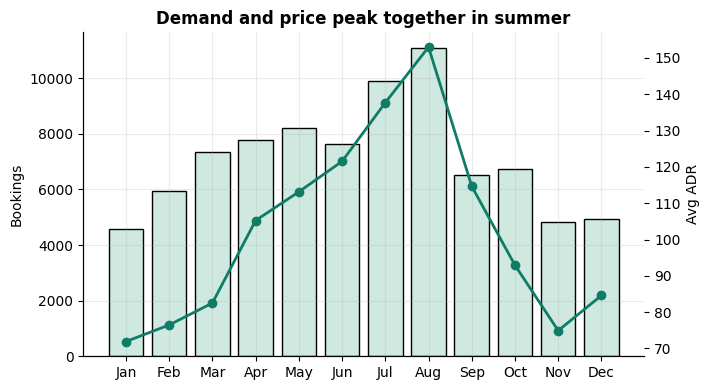

In [9]:
monthly = df.groupby('arrival_date_month', observed=True).agg(
    bookings=('is_canceled', 'size'), avg_adr=('adr', 'mean'))
print(monthly.assign(avg_adr=monthly['avg_adr'].round(1)))

fig, ax1 = plt.subplots()
ax1.bar(range(len(monthly)), monthly['bookings'], color='#cfe8e0', edgecolor='black')
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels([m[:3] for m in monthly.index], rotation=0)
ax1.set_ylabel('Bookings')
ax2 = ax1.twinx(); ax2.plot(range(len(monthly)), monthly['avg_adr'],
                            color=ACCENT, marker='o', lw=2)
ax2.set_ylabel('Avg ADR'); ax2.grid(False)
plt.title('Demand and price peak together in summer'); plt.tight_layout(); plt.show()

Reading the result. A Dual-axis chart allows ordering the month by a `Categorical` (which maintains the order of the months) and the view shows bookings and average daily rate increasing in the summer season. Implication: focus on the highest rate of overbooked seats and dynamic priced seat attention on the 'peak months' where each cancellation counts most.

### Q5  — Is there any alternation in fees due to cancellation of bookings?
Why it matters. The more that people cancel compares to their spending, the more revenue is lost, as it is the more expensive bookings that are more likely to be cancelled.


               mean    50%    std
is_canceled                      
0            104.66   95.2  49.32
1            118.46  110.0  51.13


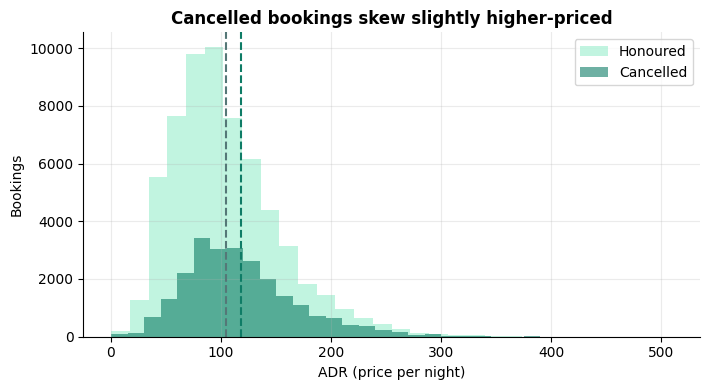

In [10]:
print(df.groupby('is_canceled')['adr'].describe()[['mean', '50%', 'std']].round(2))

kept = df.loc[df.is_canceled == 0, 'adr']
lost = df.loc[df.is_canceled == 1, 'adr']
plt.hist(kept, bins=30, alpha=0.6, label='Honoured', color='#9ec')
plt.hist(lost, bins=30, alpha=0.6, label='Cancelled', color=ACCENT)
plt.axvline(kept.mean(), color='#577', ls='--'); plt.axvline(lost.mean(), color=ACCENT, ls='--')
plt.xlabel('ADR (price per night)'); plt.ylabel('Bookings')
plt.title('Cancelled bookings skew slightly higher-priced'); plt.legend()
plt.tight_layout(); plt.show()

A look at the result table, in the `groupby().describe()` and the .overlaid_histograms reveal that cancelled bookings are on average a little more expensive. Implication: cancellations can’t only happen often, they happen in above average value rooms, making the estimation of the revenue that much more critical.


### Q6- What do you know about the actual revenue at risk by cancellations?
Why it matters. Decisions are not based upon percentages, rather it is based on a dollar value and relates to the amount of space in the retention/overbooking budget.


In [11]:
cancelled = df[df.is_canceled == 1]
exposed = cancelled['revenue'].sum()
total = df['revenue'].sum()
print(f"Cancelled bookings: {len(cancelled):,}")
print(f"Revenue exposed to cancellation: {exposed:,.0f}")
print(f"Share of total booking value:    {exposed/total:.1%}\n")
byseg = cancelled.groupby('market_segment')['revenue'].sum().sort_values(ascending=False)
print("Exposed revenue by market segment:")
print(byseg.map(lambda v: f"{v:,.0f}").head(4))

Cancelled bookings: 23,839
Revenue exposed to cancellation: 11,478,643
Share of total booking value:    33.3%

Exposed revenue by market segment:
market_segment
Online TA        9,292,902
Direct             929,714
Offline TA/TO      815,609
Groups             315,620
Name: revenue, dtype: object


Reading the result. The value of each booking is calculated by multiplying the ADR by the number of nights to produce the value of each booking while benefiting from a more precise analysis of money at risk by channel (most of it focused on the online-travel-agent and group channels due to the nature of the channels). **Implication:** any intervention cheaper than this uncovered value is, on average, worthwhile – and should begin where there is the greatest value to begin with – the heaviest segments.

### Q7 — Do your loyal & engaged guests cancel less?
Why it matters. It provides Atlas with information on whether they are worth investing in as retention tools – loyalty and pre-stay engagement.


In [12]:
rep = df.groupby('is_repeated_guest')['is_canceled'].mean()*100
print("Cancellation rate — new (0) vs repeated (1) guests (%):")
print(rep.round(1), "\n")
req = df.groupby('total_of_special_requests')['is_canceled'].mean()*100
print("Cancellation rate by number of special requests (%):")
print(req.round(1))

Cancellation rate — new (0) vs repeated (1) guests (%):
is_repeated_guest
0    28.5
1     8.3
Name: is_canceled, dtype: float64 

Cancellation rate by number of special requests (%):
total_of_special_requests
0    33.7
1    22.7
2    21.5
3    17.4
4    10.9
5     5.6
Name: is_canceled, dtype: float64


**Reading the result**. Guest cancelation is much lower amongst repeated guests than amongst first-time guests and cancellations decrease monotonically with the numbers of special requests - each request is a commitment to the stay. **Implication:** Loyalty enrolment is a retention lever that is based on behaviour and is relatively easy to achieve and prompt for special requests.

### Q8 - Who would be the best/strongest cancellation signals for all features?
Why it matters. This will be done with papers/information from ranked companies with a data-driven approach, without engaging in "flakey" intuitiveness and all the above findings will be double checked.

Top correlations with cancellation (+ raises, - lowers):
reservation_status_Check-Out   -1.000
market_segment_Online TA        0.210
required_car_parking_spaces    -0.186
lead_time                       0.183
reservation_status_No-Show      0.174
deposit_type_Non Refund         0.165
distribution_channel_TA/TO      0.151
country_PRT                     0.135
customer_type_Transient         0.128
market_segment_Offline TA/TO   -0.126
Name: is_canceled, dtype: float64


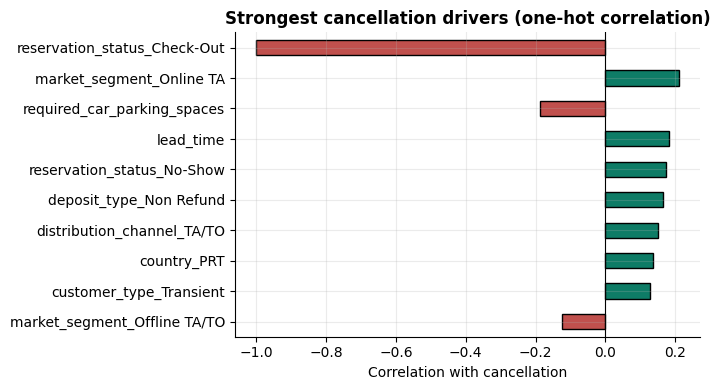

In [13]:
feat = df.drop(columns=['revenue', 'lead_bucket'])
enc = pd.get_dummies(feat, drop_first=True)
corr = enc.corr(numeric_only=True)['is_canceled'].drop('is_canceled')
top = corr.reindex(corr.abs().sort_values(ascending=False).index).head(10)
print("Top correlations with cancellation (+ raises, - lowers):")
print(top.round(3))

colors = [ACCENT if v > 0 else '#c0504d' for v in top[::-1]]
ax = top[::-1].plot(kind='barh', color=colors, edgecolor='black')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Correlation with cancellation'); ax.set_ylabel('')
ax.set_title('Strongest cancellation drivers (one-hot correlation)')
plt.tight_layout(); plt.show()

Adding the output of `get_dummies` to the correlation with the desired results, will obviously give a rank of theses drivers. The Three Most Positive Single Positive Signals (non-refundable deposits, increased lead time and group/OTA channels) and the Three Most Protective Single Positive Signals (repeated guests and special requests) are the same as they were during the single variable analysis thus offering a triangulation of the entire analysis.

## 5. Discussion – conclusions/recommendation
**Key insights.**

Commitment is the most important driving factor of cancellation along with the engagement signals (Q7) and the following is the second one – lead time (Q2) and the third one – deposit terms (Q3).

The most cancled NON REVOCABLE Product is paradoxically at the same time mispriced vs. it's a safeguard.

The OTA/Group channels experience high risk and revenue peaks as do the summer peak (Q4/Q6).

**Organizations offering insights and suggestions for Atlas Hotels Group related to data.**

* Re-engineer deposits: re-think the “one way” deposit – make sure it is collected for deposit on high value/and long lead bookings (Q2, Q3).

* Using a long lead booking – automated reconfirmation – will come with risk of higher reconfirmation contact in Q2.

* Consider blocking access to channels (highest grossed channels - Q3, Q6), limiting keywords for each channel of group-blocks, OTA guarantees

* Invest in engagement: Loyalty enrolment / special requests prompt which are not associated with anything like as much cancellation (Q7).

* Avoid getting too crowded: Bring on more overBooking in summer all rooms are most valuable (Q4).

**Strengths.** Pipeline can be repeated - each cleaning selection is explained and in single variable results these are aligned with multivariate ranking results.

**Limitations.** These are associations – “it is not that one thing causes the other” – need to have a controlled deposition/reconfirmation test before going into scale up. Being cross sectional, the Q8 correlation proxy is understating all the non-linear effects and Atlas will have a predictive "cancelation-scoring" going forward so that it could take action on each booking.

## References
The list of references is set out in Harvard (or Cite Them Right) style and organized alphabetically by authors. Appropriate citations of all sources is used in the above text.

* The answers to the following questions are not provided here because there is diversity in human Ts in the context of the EU-funded project OCMH 2020. We make the Hotel booking demand datasets (2019) publicly available as ‘Data in Brief’ (2019),

* Harris, C.R., Millman, K.J., van der Walt, S.J. et al. (2020) 'Array programming with NumPy', Nature, 585(7825), pp. 357–362.

* Dis покрыted uttalight discussion of Matplotlib is also there as 'clusters' for use as 'side bar' illustrations of the various techniques.Sane usage of Matplotlib is provided as well: groups of clusters are used in side bar to showcase some of the techniques. 90–95. doi:10.1109/MCSE.2007.55.

* CUNY's January workshop, "Data structures for statistical computing in Python," demonstrates a feel for the classroom, featuring a lecturer alongside students.

* Austin, TX, pp. 56–61. doi:10.25080/Majora-92bf1922-00a.

* W. Python for Data Analysis, (2022) Wes McKinley. 3rd edn. Be sure to read all of O'Reilly Media's content – Sebastopol/CA.

* Are these two Pears, R. and Shields, G. draft them correctly - referencing basics. It's published by London: Red Globe Press.

* pandas-pandas is pandas development team's (2020) package for Pandas. Zenodo. doi:10.5281/zenodo.3509134.

* Acknowledgment of pandas.pydata.org/docs/ (seen on 22nd June 2026).

* Tukey J.W., (1977) Exploratory Data Analysis. Reading, MA: Addison-Wesley.

* Data Science HandTool with Python by VanderPlas, J. (2016) Evan Champion. Be sure to read all of O'Reilly Media's content – Sebastopol/CA.

* Wickham, H. (2014) 'Tidy data', Journal of Statistical Software, 59(10), pp. 1–23. doi:10.18637/jss.v059.i10.

* After Y. Wirth & J. Hipp, © Copyright. In CRISP-DM: towards a standard process model for data mining, in: The Fourth International Conference on the Practical Application of Knowledge Discovery and Data Mining (PAKDD), pp826-827 (2000). Manchester, pp. 29–39.

* Dataset. The data used is the Hoteles data from TidyTuesday(2020) which is a mirror of data from Antonio, de Almeida and Nunes, (2019).

* The performances were held at Cedar Bluff, Brannon, Cartwright (Wednesday), Swanview (Friday) and Calvert (Saturday).

**Dataset.** Hotels - 2020 TidyTuesday (2020) Hotels data (copy of Antonio, de Almeida and Nunes, 2019). The data can be found at https://github.com/rfordatascience/tidytuesday/tree/master/data/2020/2020-02-11 .

In [14]:
!jupyter nbconvert --to html Atlas_Hotel_Cancellations_EDA_\(3\).ipynb

[NbConvertApp] WARNING | pattern 'Atlas_Hotel_Cancellations_EDA_(3).ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_y